# Stages 2-5: Live Collector, Inference, API & Monitoring

Everything above trains and backtests on *historical* data. This notebook walks
through the live half of the system - real-time AEMO data collection, one-step-ahead
inference, and monitoring - by reading `data/live/aemo.db`, the single database that
ties it all together:

```
collector (Stage 2)  -->  data/live/aemo.db  <--  inference (Stage 3)
                                   ^
                                   |
                        backend API (Stage 4) --> dashboard (Stage 4)
                                   |
                     monitoring endpoints (Stage 5)
```

`collector/` and `inference/` are standalone processes - they poll/predict on their
own schedule and are the only writers to the database. This notebook, like the API,
only *reads* it, so running these cells is always safe.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / "config.yaml").exists() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
REPO_ROOT

WindowsPath('C:/dev/Electricity-Demand-Forecasting-Using-Statistical-Machine-Learning-and-Deep-Learning-Methods')

In [2]:
import sqlite3

import pandas as pd
import yaml

with open(REPO_ROOT / "config.yaml") as f:
    config = yaml.safe_load(f)

conn = sqlite3.connect(REPO_ROOT / config["data"]["db_path"])
target_col = config["data"]["target_col"]

## Stage 2: what the collector has stored

In [3]:
pd.read_sql_query(
    "SELECT COUNT(*) AS n_observations, MIN(interval_datetime) AS earliest, MAX(interval_datetime) AS latest "
    "FROM observations",
    conn,
)

,n_observations,earliest,latest
0,88560,2025-08-03T00:00:00,2026-08-06T23:30:00


Recent collector runs - each poll fetches whatever's newer than the database's latest stored interval:

In [4]:
pd.read_sql_query("SELECT * FROM collector_health ORDER BY polled_at DESC LIMIT 10", conn)

,id,polled_at,files_checked,rows_inserted,error
0,2,2026-08-06T19:07:41.798135,1,5,None
1,1,2026-08-06T18:58:52.782989,575,2875,None


## Reconstructing hourly NEM demand from raw observations\n\nSame aggregation logic as the historical pipeline (`aggregate_regions_to_nem_total` + `resample_to_hourly`), plus a check that drops the most recent hour if it isn't backed by a full pair of half-hourly readings yet.

In [5]:
from inference.features import load_hourly_demand

hourly = load_hourly_demand(conn)
print(f"{len(hourly)} complete hourly observations, latest: {hourly.index.max() if len(hourly) else 'none yet'}")
hourly.tail()

8856 complete hourly observations, latest: 2026-08-06 23:00:00


,demand_nsw1,demand_qld1,demand_sa1,demand_tas1,demand_vic1,demand
timestamp,,,,,,
2026-08-06 19:00:00,11492.5,7549.0,2007.0,1403.0,8003.0,30454.5
2026-08-06 20:00:00,11368.5,7335.5,1983.5,1378.0,7748.5,29814.0
2026-08-06 21:00:00,10956.0,7322.0,1889.5,1345.5,7379.5,28892.5
2026-08-06 22:00:00,10202.0,7026.5,1758.0,1272.0,6793.5,27052.0
2026-08-06 23:00:00,9510.0,6542.0,1586.0,1195.0,6345.5,25178.5


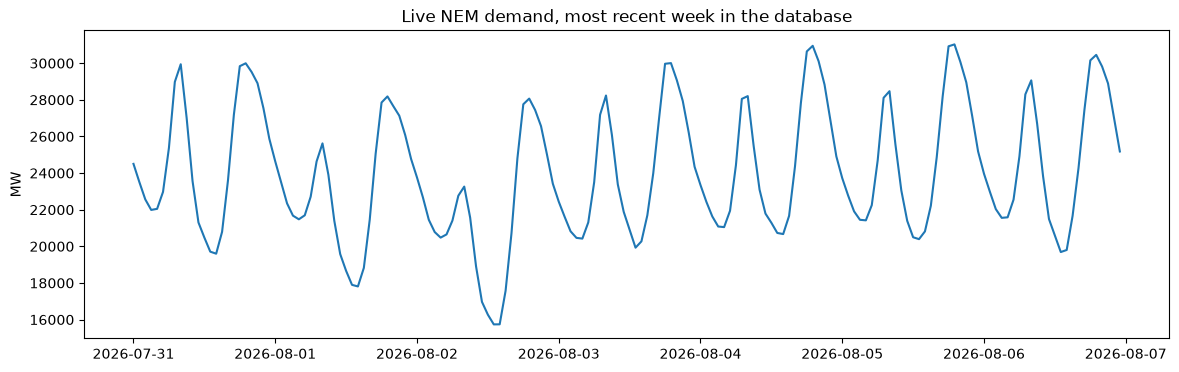

In [6]:
import matplotlib.pyplot as plt

recent = hourly.tail(24 * 7)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(recent.index, recent[target_col])
ax.set_title("Live NEM demand, most recent week in the database")
ax.set_ylabel("MW")
plt.show()

## Stage 3: live inference

`inference/predictor.py`'s `build_forecast_row()` extends the hourly series one hour
past the last complete observation and engineers features for that new hour -
calendar features of the target hour are known in advance, lag/rolling features fall
out of shifting the real series, so this is a genuine one-step-ahead forecast, not a
same-hour nowcast. This is a pure function (no DB write), so it's safe to call here
purely to inspect what the model actually sees:

In [7]:
from inference.predictor import build_forecast_row

if len(hourly) > 0:
    row, target_ts, based_on = build_forecast_row(
        hourly, target_col, config["features"]["lags"], config["features"]["rolling_windows"]
    )
    print(f"forecasting {target_ts}, based on the actual demand at {based_on}")
    display(row[[c for c in row.columns if "lag" in c or "roll" in c]])
else:
    print("no observations in the database yet")

forecasting 2026-08-07 00:00:00, based on the actual demand at 2026-08-06 23:00:00


,demand_lag_1,demand_lag_2,demand_lag_6,demand_lag_24,demand_lag_48,demand_lag_168,demand_roll_mean_3,demand_roll_std_3,demand_roll_mean_6,demand_roll_std_6,demand_roll_mean_12,demand_roll_std_12,demand_roll_mean_24,demand_roll_std_24,demand_roll_mean_168,demand_roll_std_168
timestamp,,,,,,,,,,,,,,,,
2026-08-07,25178.5,27052.0,30154.0,23961.5,23722.5,24502.0,27041.0,1857.024434,28590.916667,2074.411228,25417.125,4145.919292,24747.875,3470.835125,24012.827381,3558.772428


What `inference/run.py` has actually predicted and stored (the API's `/forecast/latest` and `/demand/predictions` read straight from this table):

In [8]:
pd.read_sql_query("SELECT * FROM predictions ORDER BY target_timestamp DESC LIMIT 10", conn)

,id,target_timestamp,based_on_timestamp,predicted_demand,model_version,predicted_at
0,1,2026-08-07T00:00:00,2026-08-06T23:00:00,23959.515625,v1,2026-08-08T14:56:56.736144


In [9]:
pd.read_sql_query("SELECT * FROM inference_health ORDER BY run_at DESC LIMIT 10", conn)

,id,run_at,predicted,error
0,2,2026-08-08T14:57:28.847271,1,None
1,1,2026-08-08T14:56:56.736144,1,None


## Stage 5: live forecast accuracy

The API's `/monitoring/accuracy` endpoint, called directly here: it joins stored
predictions to the actual demand their target hour turned out to have, once the
collector has caught up to it. This is the only true measure of live accuracy - the
Stage 1 backtest above evaluates the model on historical data it was never really
forecasting *into the future* for.

In [10]:
from backend.db import rolling_accuracy

accuracy = rolling_accuracy(conn, limit=200)
print(f"predictions scored: {accuracy['n']}")
if accuracy["n"] > 0:
    print(f"MAE={accuracy['mae']:.0f}  RMSE={accuracy['rmse']:.0f}  MAPE={accuracy['mape']:.1f}%")
else:
    print("No prediction has matured into an actual observation yet - the collector needs to catch up")
    print("to a prediction's target hour before it can be scored.")

predictions scored: 0
No prediction has matured into an actual observation yet - the collector needs to catch up
to a prediction's target hour before it can be scored.


In [11]:
if accuracy["n"] > 0:
    points = pd.DataFrame(accuracy["points"])
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(points["timestamp"], points["actual"], label="Actual", marker="o")
    ax.plot(points["timestamp"], points["predicted"], label="Predicted", marker="o")
    ax.legend()
    ax.set_title("Live forecast accuracy: predicted vs actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Stage 4: API + dashboard

`backend/` (FastAPI) is deliberately read-only and model-free - it never loads a
model or runs inference itself, only shapes what `collector/` and `inference/` have
already written for `dashboard/` (React) to render:

| Endpoint | What |
|---|---|
| `GET /health` | DB/model presence, latest observation & prediction, last collector/inference run |
| `GET /demand/chart?hours=168` | Actual + predicted merged into one series |
| `GET /forecast/latest` | The most recent (next-hour) forecast |
| `GET /monitoring/accuracy` | The rolling accuracy computed above |
| `GET /monitoring/collector`, `/monitoring/inference` | Recent process health |
| `GET /metrics/offline` | Stage 1's offline backtest comparison |

A real run of the dashboard, screenshotted against this same database:

![AEMO NEM live demand dashboard](../reports/figures/dashboard_screenshot.png)

## Summary

- **Stage 1** - historical AEMO data -> cleaned, feature-engineered, hourly NEM
  demand; XGBoost beats a seasonal-naive baseline with a statistically significant
  ~1.7% test MAPE.
- **Stage 2** - a standalone collector polls AEMO's live feed every 5 minutes into
  `data/live/aemo.db`, self-catching-up and safe to run cold or after downtime.
- **Stage 3** - a standalone inference job turns the latest complete hour into a
  genuine one-step-ahead forecast using the exact same feature-engineering code
  training used, and stores it idempotently.
- **Stage 4** - a read-only FastAPI service and React dashboard surface all of the
  above.
- **Stage 5** - rolling live-accuracy and collector/inference health, so the system
  can be judged on how it's actually performing in production, not just on a
  historical backtest.